In [1]:
from nnfs.datasets import spiral_data
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from tensorflow import keras
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import shutil
import os
sns.set()

2022-09-10 21:34:37.186920: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-09-10 21:34:37.325088: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2022-09-10 21:34:37.325112: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2022-09-10 21:34:37.351143: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2022-09-10 21:34:37.945940: W tensorflow/stream_executor/platform/de

In [2]:
# X, y = make_circles(10000, noise=.03, random_state=43)
X, y = spiral_data(samples=5000, classes=2)

In [3]:
X.shape, y.shape

((10000, 2), (10000,))

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=.2,
    random_state=42
)

X_train.shape, y_train.shape

((8000, 2), (8000,))

In [5]:
df = pd.DataFrame(np.append(X, y.reshape(-1, 1), axis=1), columns=['X1', 'X2', 'y'])
df

,X1,X2,y
0,0.000000,0.000000,0.0
1,-0.000160,0.000121,0.0
2,0.000140,0.000375,0.0
3,-0.000106,0.000591,0.0
4,-0.000658,0.000455,0.0
...,...,...,...
9995,0.744810,0.666077,1.0
9996,0.992104,-0.120539,1.0
9997,0.665442,0.745914,1.0
9998,0.895525,0.444561,1.0


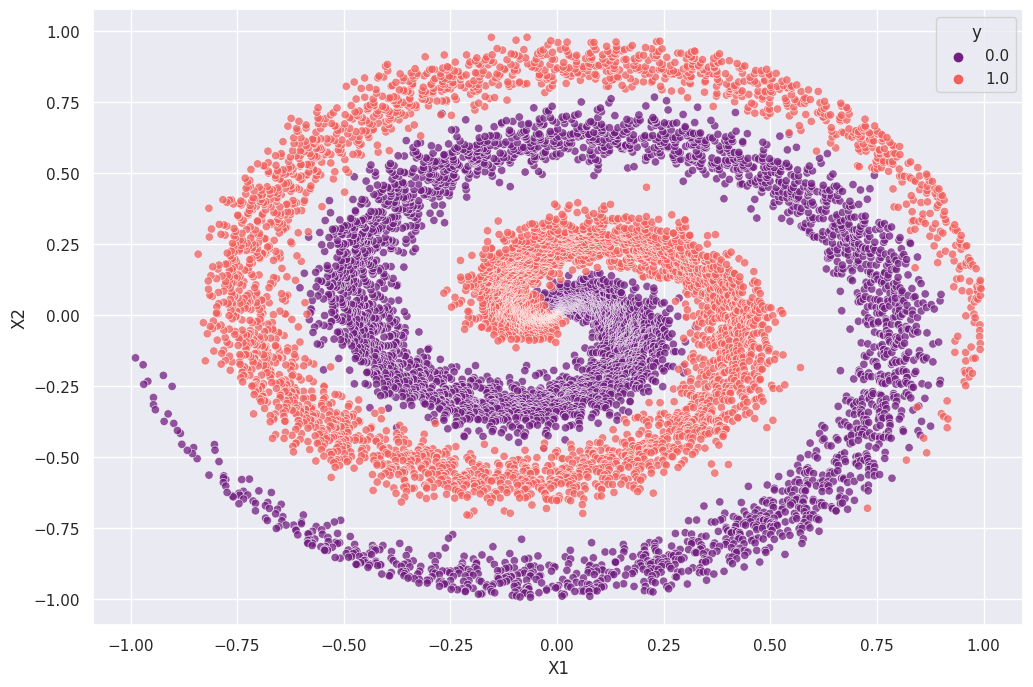

In [6]:
pallete = {
  0: 'tab:red',
  1: 'tab:green',
  2: 'tab:blue'
}

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='X1', y='X2', hue='y', palette='magma', alpha=.75)
plt.show()

In [7]:
class StoreContent:
  def __init__(self, name_dir):
    self.name_dir = name_dir
    self.pwd = os.getcwd()

  def delete_dir(self):
    if os.path.isdir(self.name_dir):
      shutil.rmtree(self.name_dir)
    else:
      print('folder telah dihapus')

  def store_data(self, data, separate=False, second_dir={}):
    '''
    paramater data harus merupakan dictionary, misal data={nama_file:nilai_data}
    '''
    
    dir_name = os.path.join(self.pwd, self.name_dir)

    if separate:
      for folder_names, values in second_dir.items():
        if not os.path.isdir(f'{dir_name}/{folder_names}'):
          os.makedirs(f'{dir_name}/{folder_names}')
        
        np.save(f'{dir_name}/{folder_names}/epoch_{data}.npy', values)
    
    else:
      assert type(data) == dict, 'nilai data harus bertipe dictionary'
      if not os.path.isdir(self.name_dir):
        os.mkdir(dir_name)
      for filename, value in data.items():
        np.save(f'{dir_name}/{filename}.npy', value)


class PerformancePlotCallback(StoreContent, keras.callbacks.Callback):
    def __init__(self, name_dir, x, y):
      super().__init__(name_dir)
      self.x = x
      self.y = y

        
    def on_epoch_end(self, epoch, logs=None):
        x_min, x_max = self.x[:, 0].min() - 0.1, self.x[:, 0].max() + 0.1
        y_min, y_max = self.x[:, 1].min() - 0.1, self.x[:, 1].max() + 0.1
        xx, yy = np.meshgrid(
          np.linspace(x_min, x_max, 100),
          np.linspace(y_min, y_max, 100)
        )

        x_in = np.c_[xx.ravel(), yy.ravel()]
        
        y_pred = self.model.predict(x_in)

        if len(y_pred[0]) > 1:
          y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
        else:
          y_pred = np.round(y_pred).reshape(xx.shape)
        
        self.store_data(
          epoch, 
          separate=True, 
          second_dir={
            'loss_history': logs['loss'], 
            'accuracy': logs['accuracy'], 
            'prediction_history': y_pred
          })
        
        # JIKA KASUS REGRESI
        '''
          # df = pd.DataFrame()
          # series = pd.Series(y_pred.ravel())
          # df[epoch] = series
          # df.to_csv(f'../datasets/training/epoch_{epoch}.csv')
        '''

def plot_decision_boundary(model, X, y):
    np.random.seed(43)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )
    
    x_in = np.c_[xx.ravel(), yy.ravel()]
    y_pred = model.predict(x_in)

    if len(y_pred[0]) > 1:
      y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
      y_pred = np.round(y_pred).reshape(xx.shape)

    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='white', linewidths=.05)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()


# 'Datasets_Classification'

In [8]:
create_container = StoreContent('data_source')
create_container.delete_dir()
create_container.store_data({
    'X':X, 
    'y':y, 
    'X_train':X_train, 
    'y_train':y_train,
    'X_test':X_test,
    'y_test':y_test
})

folder telah dihapus


In [9]:
checkpoint = keras.callbacks.ModelCheckpoint("../models/spiral_data.h5", save_best_only=True)
performance = PerformancePlotCallback('history', x=X, y=y)

# performance.delete_dir()
model = keras.Sequential([
  keras.layers.Dense(32, activation='relu'),
  keras.layers.Dense(32, activation='relu'),
  keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
  loss=keras.losses.BinaryCrossentropy(),
  optimizer=keras.optimizers.Adam(),
  metrics=['accuracy']
)

history = model.fit(
  X_train, 
  y_train, 
  epochs=60, 
  verbose=1
  # callbacks=[checkpoint, performance],
  # batch_size=32,
)

Epoch 1/60


2022-09-10 21:34:39.957336: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2022-09-10 21:34:39.957377: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2022-09-10 21:34:39.957397: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (anggads01): /proc/driver/nvidia/version does not exist
2022-09-10 21:34:39.957605: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


250/250 [==============================] - 1s 1ms/step - loss: 0.6710 - accuracy: 0.6072
Epoch 2/60
250/250 [==============================] - 0s 2ms/step - loss: 0.6624 - accuracy: 0.6211
Epoch 3/60
250/250 [==============================] - 0s 2ms/step - loss: 0.6560 - accuracy: 0.6236
Epoch 4/60
250/250 [==============================] - 0s 2ms/step - loss: 0.6425 - accuracy: 0.6231
Epoch 5/60
250/250 [==============================] - 0s 1ms/step - loss: 0.6179 - accuracy: 0.6289
Epoch 6/60
250/250 [==============================] - 0s 2ms/step - loss: 0.5822 - accuracy: 0.6735
Epoch 7/60
250/250 [==============================] - 0s 2ms/step - loss: 0.5347 - accuracy: 0.7486
Epoch 8/60
250/250 [==============================] - 0s 2ms/step - loss: 0.4796 - accuracy: 0.7846
Epoch 9/60
250/250 [==============================] - 0s 1ms/step - loss: 0.4204 - accuracy: 0.8371
Epoch 10/60
250/250 [==============================] - 0s 1ms/step - loss: 0.3624 - accuracy: 0.8850
Epoch 11/6

In [10]:
model.evaluate(X_test, y_test)

63/63 [==============================] - 0s 1ms/step - loss: 0.0322 - accuracy: 0.9905


[0.032178349792957306, 0.9904999732971191]

313/313 [==============================] - 0s 619us/step


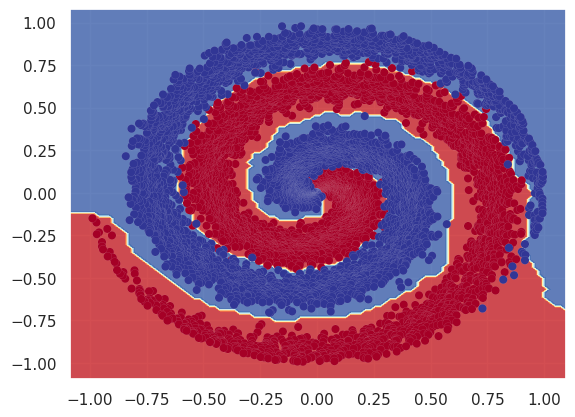

In [11]:
plot_decision_boundary(model, X, y)

63/63 [==============================] - 0s 1ms/step


variable,y pred,y test
value,,
0.0,1003,1012
1.0,997,988


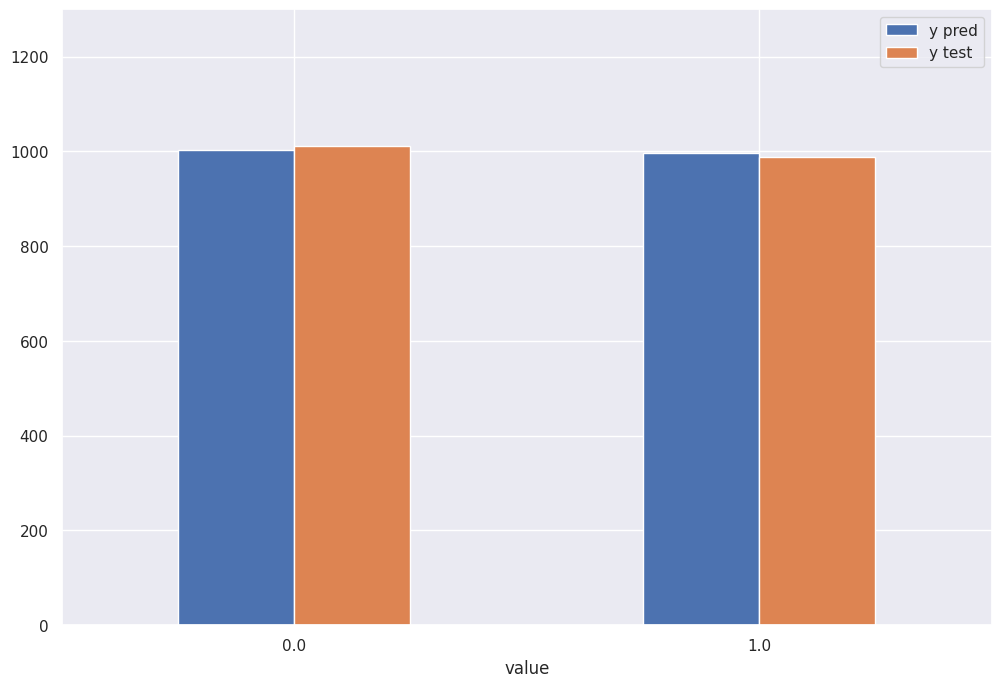

In [12]:

y_pred = np.round(model.predict(X_test))

df_compare = pd.DataFrame(np.c_[y_pred, y_test], columns=['y pred', 'y test'])

zero, one = df_compare['y pred'].value_counts()

# ax = sns.countplot(df_compare['y pred'])

# ax.annotate(
#     f'{zero}', 
#     xy=(0, zero), 
#     xytext=(0, zero + int(zero/8)), 
#     fontsize=12,
#     arrowprops=dict(facecolor='black', shrink=0.001)
# )

# ax.annotate(
#     f'{one}', 
#     xy=(1, one), 
#     xytext=(1, one + int(one/8)), 
#     fontsize=12,
#     arrowprops=dict(facecolor='black', shrink=0.001)
# )

# sns.catplot(data=df_compare.melt(), x='value', col='variable', kind='count', palette='magma_r')

df_plot = df_compare.melt().value_counts().sort_index()
display(df_plot.unstack('variable'))


df_plot.unstack('variable').plot.bar(rot=0, figsize=(12, 8))
plt.legend(loc='upper right')
plt.ylim([0, 1300])

plt.show()

In [13]:
model.evaluate(X_test, y_test)

63/63 [==============================] - 0s 1ms/step - loss: 0.0322 - accuracy: 0.9905


[0.032178349792957306, 0.9904999732971191]

<AxesSubplot:>

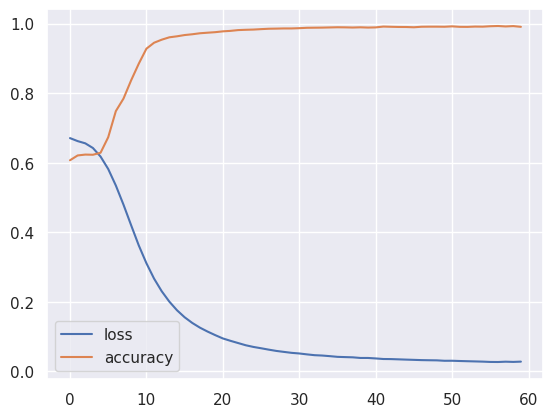

In [14]:
pd.DataFrame(history.history).plot()

In [15]:
y_pred = np.round(model.predict(X_test))
# pd.DataFrame(np.append(y_pred, y_test.reshape(-1,1), axis=1), columns=['y prediksi', 'y sebenarnya'])

63/63 [==============================] - 0s 860us/step


In [16]:
os.getcwd()

'/home/anggads01/Public/github_push_area/Python/plotting_contur_pada_hasil_prediksi'

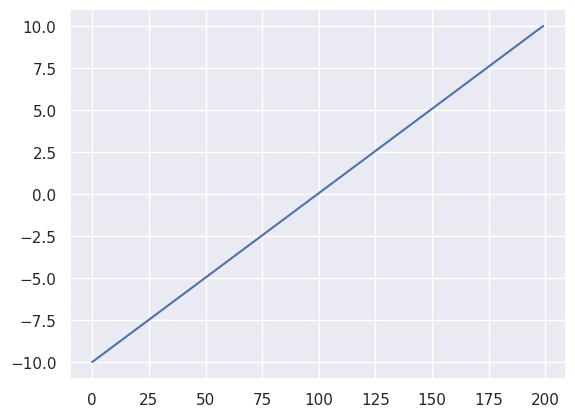

In [17]:
A = tf.constant(np.linspace(-10, 10, 200))

plt.plot(A)

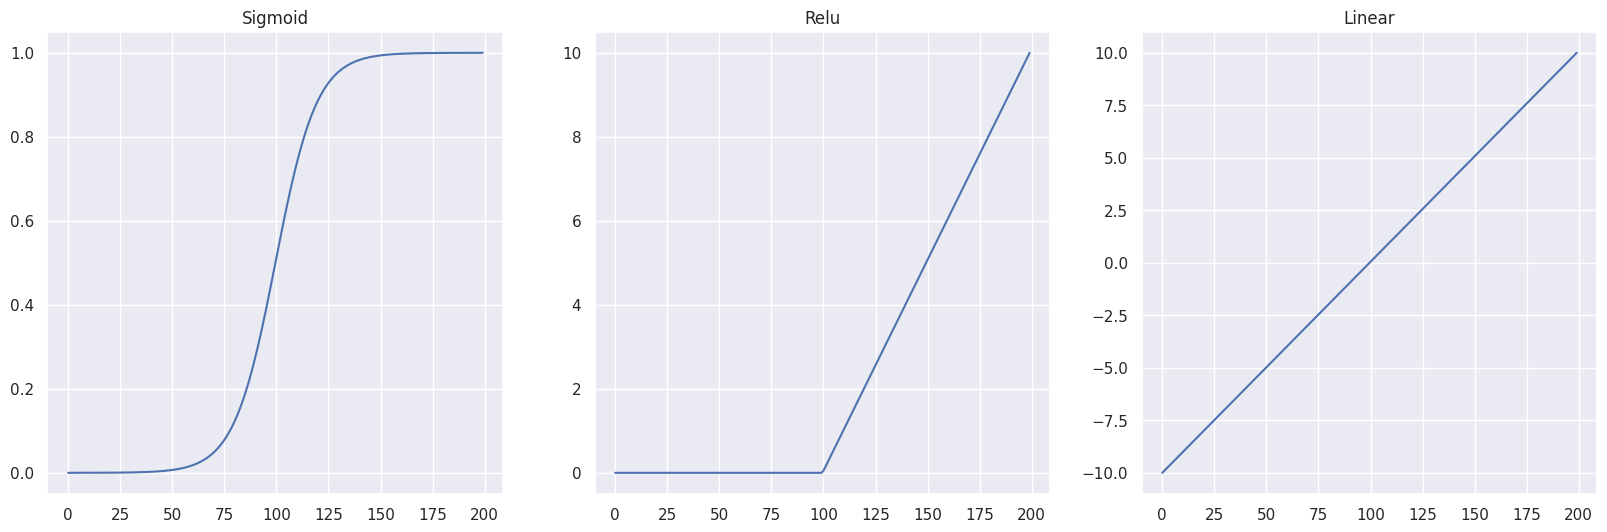

In [18]:
sigmoid = lambda x: 1 / (1 + np.exp(-x))
ReLU = lambda x: np.maximum(x, 0)

A_sigmoid = sigmoid(A)
A_relu = ReLU(A)

plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.plot(A_sigmoid)
plt.title('Sigmoid')

plt.subplot(1, 3, 2)
plt.plot(A_relu)
plt.title('Relu')

plt.subplot(1, 3, 3)
plt.plot(A)
plt.title('Linear')


plt.show()

## End Program

In [19]:
tabungan = 15000
kakak = 200
adik1 = 100

def jatah(tabungan, orang):
    assert type(orang) == dict, 'harus bernilai dict'

    tabungan_orang = {key: 0 for key in orang.keys()}
    while tabungan >= sum(orang.values()):
        for keys, val in orang.items():
            tabungan_orang[keys] += val
        tabungan -= sum(orang.values())
    return tabungan_orang, tabungan

jatah(tabungan, {'kakak':kakak, 'adik1':adik1})

({'kakak': 10000, 'adik1': 5000}, 0)

In [20]:
main_folder = 'Coba_folder'
folders = {'folder1': X[:100], 'folder2':y[:100]}

for idx, (name_folder, value) in enumerate(folders.items()):
    if not os.path.isdir(f'{main_folder}/{name_folder}'):
        os.makedirs(f'{main_folder}/{name_folder}/')
    np.save(f'{main_folder}/{name_folder}/{idx}_data.npy', value)